In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [15]:
df = pd.read_csv('IMDB Dataset.csv')

In [16]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [17]:
df.columns[:]

Index(['review', 'sentiment'], dtype='str')

In [18]:
df['sentiment']

0        positive
1        positive
2        positive
3        negative
4        positive
           ...   
49995    positive
49996    negative
49997    negative
49998    negative
49999    negative
Name: sentiment, Length: 50000, dtype: str

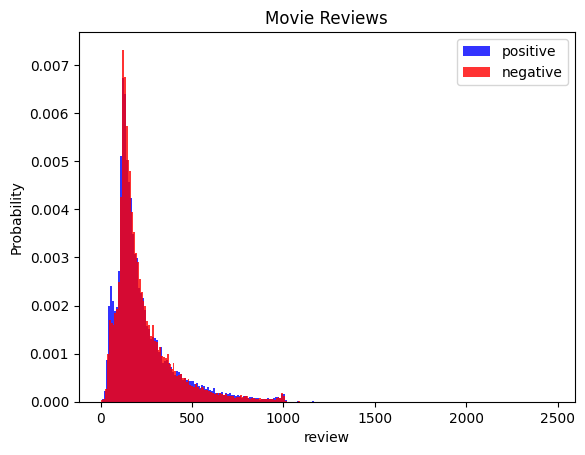

In [19]:
plt.hist(df[df['sentiment'] == 'positive']['review'].str.split().str.len() , color = 'blue' , label= 'positive' , alpha = 0.8 , density = True , bins='auto')
plt.hist(df[df['sentiment'] == 'negative']['review'].str.split().str.len()  , color = 'red' , label= 'negative' , alpha = 0.8 , density = True , bins='auto')
plt.title("Movie Reviews")
plt.xlabel('review')
plt.ylabel('Probability')
plt.legend()
plt.show()


In [20]:
df['sentiment'] = [1 if i == 'positive' else 0 for i in df['sentiment']]
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [21]:
X = df['review'].values

y = df['sentiment'].values

X.shape , y.shape

((50000,), (50000,))

In [22]:
# 60% for train , 40 for temp 
# X_temp , X_test , y_temp , y_test = train_test_split(X , y , test_size=0.5 , random_state=0)
# X_validation , X_train , y_validation , y_train = train_test_split(X_temp , y_temp , test_size=0.2 , random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [ ]:
# this will remember the most common 10000 words
encoder = tf.keras.layers.TextVectorization(max_tokens=10000)
# build the training words
encoder.adapt(X_train)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=len(encoder.get_vocabulary()) , output_dim=64 , mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),

    # tf.keras.layers.Dense(128, activation='relu'),

    # tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(64 , activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=['accuracy'])
# model.compile(
#     optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss = tf.keras.losses.BinaryCrossentropy(),
#     metrics = ['accuracy']
# )

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Encode the training and validation data
X_train_encoded = encoder(X_train)
X_test_encoded = encoder(X_test)

# Train the model for 5 epochs (full passes through the data)
history = model.fit(
    X_train_encoded, 
    y_train, 
    epochs=2, 
    batch_size=64,
    validation_data=(X_test_encoded, y_test)
)

Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 3058s 8s/step - accuracy: 0.9025 - loss: 0.2509 - val_accuracy: 0.8711 - val_loss: 0.3030
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 1629s 4s/step - accuracy: 0.9360 - loss: 0.1758 - val_accuracy: 0.8362 - val_loss: 0.3765


In [31]:
# Write your own review
sample_review = ["The special effects were amazing, but the plot was incredibly boring and made no sense."]

sample_review_encoder = encoder(sample_review)

# Ask the model to predict the sentiment
prediction = model.predict(sample_review_encoder)

# Print the result (closer to 1 is positive, closer to 0 is negative)
if prediction[0][0] >= 0.5:
    print(f"Prediction: POSITIVE (Score: {prediction[0][0]:.4f})")
else:
    print(f"Prediction: NEGATIVE (Score: {prediction[0][0]:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: NEGATIVE (Score: 0.1830)
